In [5]:
# mports & folder structure
import os, time, requests, json, numpy as np
import pandas as pd
import musicbrainzngs
from PIL import Image
from io import BytesIO
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

# Create all folders
os.makedirs('../data/covers_128',    exist_ok=True)
os.makedirs('../data/spectrograms',  exist_ok=True)
os.makedirs('../data/logs',          exist_ok=True)

print("Folders created")
print(os.listdir('../data'))

Folders created
['covers_128', '.DS_Store', 'fma_medium', 'logs', 'fma_metadata', 'spectrograms']


In [6]:
# Load metadata
tracks = pd.read_csv('../data/fma_metadata/tracks.csv', index_col=0, header=[0, 1])
print(f"Total tracks in metadata: {len(tracks)}")
print(f"Genres:\n{tracks['track']['genre_top'].value_counts().head(10)}")

Total tracks in metadata: 106574
Genres:
genre_top
Rock             14182
Experimental     10608
Electronic        9372
Hip-Hop           3552
Folk              2803
Pop               2332
Instrumental      2079
International     1389
Classical         1230
Jazz               571
Name: count, dtype: int64


In [7]:
# Scan fma_medium for actual MP3 files
skip = {'.DS_Store', 'checksums', 'README.txt'}
medium_ids = []

for folder in os.listdir('../data/fma_medium'):
    if folder in skip: continue
    fp = os.path.join('../data/fma_medium', folder)
    if not os.path.isdir(fp): continue
    for f in os.listdir(fp):
        if f.endswith('.mp3'):
            try: medium_ids.append(int(f.replace('.mp3', '')))
            except: pass

medium_tracks = tracks[tracks.index.isin(medium_ids)].copy()
print(f"MP3s found:              {len(medium_ids)}")
print(f"Matched metadata rows:   {len(medium_tracks)}")
print(f"Has artist + album:      {(medium_tracks['artist']['name'].notna() & medium_tracks['album']['title'].notna()).sum()}")
print(f"\nGenre distribution:")
print(medium_tracks['track']['genre_top'].value_counts())

MP3s found:              25000
Matched metadata rows:   25000
Has artist + album:      25000

Genre distribution:
genre_top
Rock                   7103
Electronic             6314
Experimental           2251
Hip-Hop                2201
Folk                   1519
Instrumental           1350
Pop                    1186
International          1018
Classical               619
Old-Time / Historic     510
Jazz                    384
Country                 178
Soul-RnB                154
Spoken                  118
Blues                    74
Easy Listening           21
Name: count, dtype: int64


In [8]:
# Fetch cover art (resumable, parallel)
musicbrainzngs.set_useragent("SpectroGen", "1.0", "amithajgowda10@gmail.com")

PROGRESS_FILE = '../data/logs/fetch_progress.json'
FAILED_FILE   = '../data/logs/failed.json'

progress = json.load(open(PROGRESS_FILE)) if os.path.exists(PROGRESS_FILE) else {}
failed   = json.load(open(FAILED_FILE))   if os.path.exists(FAILED_FILE)   else []

print(f"Already fetched: {len(progress)} | Failed: {len(failed)}")

def search_mbid(artist, album):
    try:
        result = musicbrainzngs.search_releases(artist=artist, release=album, limit=1)
        if result['release-list']:
            return result['release-list'][0]['id']
    except:
        pass
    return None

def fetch_cover(mbid, track_id):
    for size in [500, 250]:
        url = f"https://coverartarchive.org/release/{mbid}/front-{size}"
        try:
            r = requests.get(url, allow_redirects=True, timeout=10)
            if r.status_code == 200:
                img = Image.open(BytesIO(r.content)).convert('RGB')
                img = img.resize((128, 128), Image.LANCZOS)
                img.save(f'../data/covers_128/{track_id}.jpg', quality=95)
                return True
        except:
            continue
    return False

def process_track(args):
    track_id, artist, album = args
    mbid = search_mbid(artist, album)
    time.sleep(0.5)
    if not mbid:
        return track_id, None, False
    success = fetch_cover(mbid, track_id)
    time.sleep(0.3)
    return track_id, mbid, success

# Build todo — skip already done
done_set     = set(progress.keys())
failed_set   = set(str(k) for k in failed)
existing_128 = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))

todo = [
    (str(idx), row['artist']['name'], row['album']['title'])
    for idx, row in medium_tracks.iterrows()
    if str(idx) not in done_set
    and str(idx) not in failed_set
    and str(idx) not in existing_128
]

print(f"Already in covers_128: {len(existing_128)}")
print(f"Tracks remaining:      {len(todo)}")
print(f"Estimated time:        ~{len(todo)/1.2/3600:.1f} hours")

if len(todo) == 0:
    print("All covers already fetched!")
else:
    print("Starting fetch...")
    with ThreadPoolExecutor(max_workers=5) as executor:
        futures = {executor.submit(process_track, args): args for args in todo}
        for future in tqdm(as_completed(futures), total=len(todo)):
            track_id, mbid, success = future.result()
            if success:
                progress[track_id] = mbid
            else:
                if track_id not in failed:
                    failed.append(track_id)
            if (len(progress) + len(failed)) % 10 == 0:
                with open(PROGRESS_FILE, 'w') as f: json.dump(progress, f)
                with open(FAILED_FILE,   'w') as f: json.dump(failed, f)

    with open(PROGRESS_FILE, 'w') as f: json.dump(progress, f)
    with open(FAILED_FILE,   'w') as f: json.dump(failed, f)

    print(f"\nDone!")
    print(f"Fetched:             {len(progress)}")
    print(f"Failed:              {len(failed)}")
    print(f"Total covers_128:    {len(os.listdir('../data/covers_128'))}")

Already fetched: 0 | Failed: 0
Already in covers_128: 0
Tracks remaining:      25000
Estimated time:        ~5.8 hours
Starting fetch...


  0%|          | 0/25000 [00:00<?, ?it/s]


Done!
Fetched:             13916
Failed:              11084
Total covers_128:    13916


In [9]:
# Extract spectrograms for tracks that have covers
import librosa

cover_ids = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids  = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
todo      = cover_ids - spec_ids

print(f"Covers:              {len(cover_ids)}")
print(f"Spectrograms done:   {len(spec_ids)}")
print(f"Need extraction:     {len(todo)}")

def get_mp3_path(track_id):
    tid    = int(track_id)
    folder = f"{tid // 1000:03d}"
    path   = f"../data/fma_medium/{folder}/{tid}.mp3"
    return path if os.path.exists(path) else None

def extract_melspec(mp3_path, n_mels=64, n_fft=2048, hop_length=512, sr=22050, duration=30):
    try:
        y, sr   = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
        target  = sr * duration
        if len(y) < target:
            y   = np.pad(y, (0, target - len(y)))
        y       = y[:target]
        mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                  n_fft=n_fft, hop_length=hop_length)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)
    except:
        return None

no_mp3, failed_spec = [], []

for track_id in tqdm(todo):
    mp3_path = get_mp3_path(track_id)
    if not mp3_path:
        no_mp3.append(track_id)
        continue
    mel = extract_melspec(mp3_path)
    if mel is not None:
        np.save(f'../data/spectrograms/{track_id}.npy', mel)
    else:
        failed_spec.append(track_id)

print(f"\n✅ Done!")
print(f"Spectrograms saved:  {len(os.listdir('../data/spectrograms'))}")
print(f"No MP3 found:        {len(no_mp3)}")
print(f"Extraction failed:   {len(failed_spec)}")

Covers:              13916
Spectrograms done:   0
Need extraction:     13916


  0%|          | 0/13916 [00:00<?, ?it/s]

/var/folders/q5/fq2zbr256xsgyc0wnh48sltc0000gn/T/ipykernel_63287/2099330558.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/opt/anaconda3/envs/genai/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
[src/libmpg123/layer3.c:INT123_do_layer3():1804] error: dequantization failed!
/var/folders/q5/fq2zbr256xsgyc0wnh48sltc0000gn/T/ipykernel_63287/2099330558.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
[src/libmpg123/parse.c:do


✅ Done!
Spectrograms saved:  5461
No MP3 found:        8453
Extraction failed:   2


In [11]:
# Diagnose where the missing MP3s are
import os

cover_ids = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids  = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
no_spec   = cover_ids - spec_ids

# Check which dataset they belong to
in_small  = []
in_medium = []
nowhere   = []

for track_id in no_spec:
    tid    = int(track_id)
    folder = f"{tid // 1000:03d}"
    small  = f"../data/fma_small/{folder}/{tid}.mp3"
    medium = f"../data/fma_medium/{folder}/{tid}.mp3"
    
    if os.path.exists(medium):
        in_medium.append(track_id)
    elif os.path.exists(small):
        in_small.append(track_id)
    else:
        nowhere.append(track_id)

print(f"Missing spectrograms:      {len(no_spec)}")
print(f"  MP3 in fma_medium:       {len(in_medium)}")
print(f"  MP3 in fma_small:        {len(in_small)}")
print(f"  MP3 nowhere (orphaned):  {len(nowhere)}")

Missing spectrograms:      8455
  MP3 in fma_medium:       2
  MP3 in fma_small:        0
  MP3 nowhere (orphaned):  8453


In [12]:
# Cell — Re-extract spectrograms checking BOTH datasets
import librosa, numpy as np
from tqdm.notebook import tqdm

cover_ids = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids  = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
todo      = cover_ids - spec_ids

print(f"Still need spectrograms: {len(todo)}")

def get_mp3_path(track_id):
    tid    = int(track_id)
    folder = f"{tid // 1000:03d}"
    # Check BOTH small and medium
    for base in ['../data/fma_small', '../data/fma_medium']:
        path = f"{base}/{folder}/{tid}.mp3"
        if os.path.exists(path):
            return path
    return None

def extract_melspec(mp3_path, n_mels=64, n_fft=2048, hop_length=512, sr=22050, duration=30):
    try:
        y, sr   = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
        target  = sr * duration
        if len(y) < target:
            y   = np.pad(y, (0, target - len(y)))
        y       = y[:target]
        mel     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                  n_fft=n_fft, hop_length=hop_length)
        log_mel = librosa.power_to_db(mel, ref=np.max)
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-8)
        return log_mel.astype(np.float32)
    except:
        return None

no_mp3, failed_spec = [], []

for track_id in tqdm(todo):
    mp3_path = get_mp3_path(track_id)
    if not mp3_path:
        no_mp3.append(track_id)
        continue
    mel = extract_melspec(mp3_path)
    if mel is not None:
        np.save(f'../data/spectrograms/{track_id}.npy', mel)
    else:
        failed_spec.append(track_id)

# Final count
cover_ids   = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids    = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
valid_pairs = cover_ids & spec_ids

print(f"\n✅ Done!")
print(f"Total valid pairs:   {len(valid_pairs)}")
print(f"No MP3 anywhere:     {len(no_mp3)}")
print(f"Extraction failed:   {len(failed_spec)}")

# Genre breakdown
valid_ints = [int(v) for v in valid_pairs]
final_meta = tracks[tracks.index.isin(valid_ints)]
print("\nFinal genre distribution:")
print(final_meta['track']['genre_top'].value_counts())

Still need spectrograms: 8455


  0%|          | 0/8455 [00:00<?, ?it/s]

/var/folders/q5/fq2zbr256xsgyc0wnh48sltc0000gn/T/ipykernel_63287/3960599718.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
[src/libmpg123/parse.c:do_readahead():1083] warning: Cannot read next header, a one-frame stream? Duh...
/opt/anaconda3/envs/genai/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/var/folders/q5/fq2zbr256xsgyc0wnh48sltc0000gn/T/ipykernel_63287/3960599718.py:23: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr   = librosa.load(mp3_path, sr=sr, duration=duration, mono=True)
/opt/anaconda3/envs/genai/lib/python3.10/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will


✅ Done!
Total valid pairs:   5461
No MP3 anywhere:     8453
Extraction failed:   2

Final genre distribution:
genre_top
Rock                   1415
Electronic             1338
Instrumental            717
Hip-Hop                 577
Experimental            516
Folk                    311
Pop                     259
International           128
Classical                87
Old-Time / Historic      44
Spoken                   21
Jazz                     19
Soul-RnB                 14
Blues                     7
Country                   6
Easy Listening            2
Name: count, dtype: int64


In [15]:
# Cell — Move orphaned covers to a separate folder (safe, recoverable)
import os, shutil

os.makedirs('../data/covers_orphaned', exist_ok=True)

cover_ids = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids  = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
orphaned  = cover_ids - spec_ids

print(f"Moving {len(orphaned)} orphaned covers to covers_orphaned/...")

moved  = 0
failed = []
for tid in orphaned:
    src = f'../data/covers_128/{tid}.jpg'
    dst = f'../data/covers_orphaned/{tid}.jpg'
    try:
        shutil.move(src, dst)
        moved += 1
    except Exception as e:
        failed.append((tid, str(e)))

# Verify
cover_ids   = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids    = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
valid_pairs = cover_ids & spec_ids
orphaned_ct = len(os.listdir('../data/covers_orphaned'))

print(f"\nDone!")
print(f"Moved to covers_orphaned/:  {moved}")
print(f"Failed to move:             {len(failed)}")
print(f"covers_128/ now:            {len(cover_ids)}  (all valid)")
print(f"spectrograms/:              {len(spec_ids)}")
print(f"Valid pairs:                {len(valid_pairs)}")
print(f"covers_orphaned/:           {orphaned_ct}  (safe, recoverable)")

# Genre breakdown
valid_ints = [int(v) for v in valid_pairs]
final_meta = tracks[tracks.index.isin(valid_ints)]
print("\nFinal genre distribution:")
print(final_meta['track']['genre_top'].value_counts())

Moving 0 orphaned covers to covers_orphaned/...

Done!
Moved to covers_orphaned/:  0
Failed to move:             0
covers_128/ now:            5461  (all valid)
spectrograms/:              5461
Valid pairs:                5461
covers_orphaned/:           8455  (safe, recoverable)

Final genre distribution:
genre_top
Rock                   1415
Electronic             1338
Instrumental            717
Hip-Hop                 577
Experimental            516
Folk                    311
Pop                     259
International           128
Classical                87
Old-Time / Historic      44
Spoken                   21
Jazz                     19
Soul-RnB                 14
Blues                     7
Country                   6
Easy Listening            2
Name: count, dtype: int64


       SPECTROGEN — DATASET SUMMARY
Valid pairs:          5461
Image resolution:     128 × 128 px
Spectrogram shape:    (64, 1292)
Orphaned (saved):     8455
Future pairs (fma_large): ~13,900+

Genre distribution:
genre_top
Rock                   1415
Electronic             1338
Instrumental            717
Hip-Hop                 577
Experimental            516
Folk                    311
Pop                     259
International           128
Classical                87
Old-Time / Historic      44
Spoken                   21
Jazz                     19
Soul-RnB                 14
Blues                     7
Country                   6
Easy Listening            2
Name: count, dtype: int64


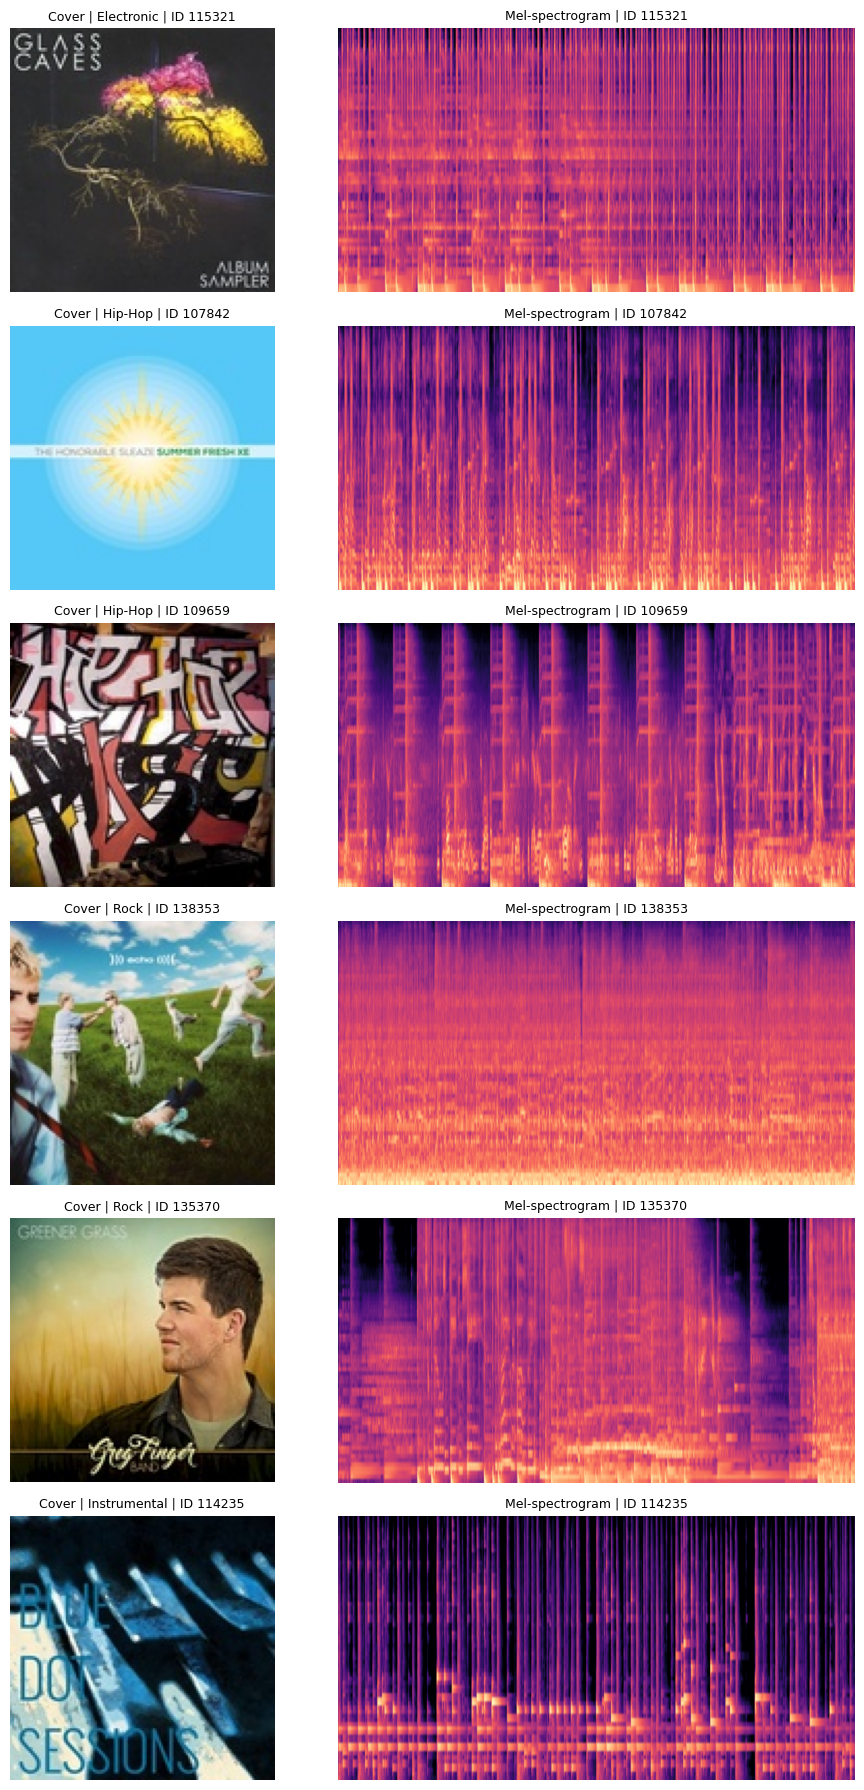

In [17]:
# Final dataset summary
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

cover_ids   = set(f.replace('.jpg','') for f in os.listdir('../data/covers_128') if f.endswith('.jpg'))
spec_ids    = set(f.replace('.npy','') for f in os.listdir('../data/spectrograms') if f.endswith('.npy'))
valid_pairs = sorted(cover_ids & spec_ids)

print("=" * 45)
print("       SPECTROGEN — DATASET SUMMARY")
print("=" * 45)
print(f"Valid pairs:          {len(valid_pairs)}")
print(f"Image resolution:     128 × 128 px")
print(f"Spectrogram shape:    {np.load(f'../data/spectrograms/{valid_pairs[0]}.npy').shape}")
print(f"Orphaned (saved):     {len(os.listdir('../data/covers_orphaned'))}")
print(f"Future pairs (fma_large): ~13,900+")
print("=" * 45)

valid_ints = [int(v) for v in valid_pairs]
final_meta = tracks[tracks.index.isin(valid_ints)]
print("\nGenre distribution:")
print(final_meta['track']['genre_top'].value_counts())

# Plot 6 random pairs
sample_ids = random.sample(valid_pairs, 6)
fig, axes  = plt.subplots(6, 2, figsize=(10, 18))

for i, tid in enumerate(sample_ids):
    try:    genre = tracks.loc[int(tid)]['track']['genre_top']
    except: genre = 'Unknown'

    img = Image.open(f'../data/covers_128/{tid}.jpg')
    mel = np.load(f'../data/spectrograms/{tid}.npy')

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Cover | {genre} | ID {tid}', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(mel, aspect='auto', origin='lower', cmap='magma')
    axes[i, 1].set_title(f'Mel-spectrogram | ID {tid}', fontsize=9)
    axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('../data/logs/final_dataset.png', dpi=120)
plt.show()